<a href="https://colab.research.google.com/github/lhammach/DP-representations/blob/main/cka_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CKA analysis of ResNet18 representations on CIFAR-10

This notebook compares internal representations learned by two ResNet18 models trained on CIFAR-10:

- a **baseline** model trained without differential privacy,
- a **DP-SGD** model trained with **Opacus**.

The comparison is performed using **Centered Kernel Alignment (CKA)** on intermediate activations extracted from the test set.

## Goal

We want to measure how similar the internal representations of the two trained models are across depth.

## Implementation note

The DP model was made compatible with Opacus during training by:
- replacing **BatchNorm** with **GroupNorm**,
- disabling **inplace ReLU** operations,
- patching the `BasicBlock` residual addition to avoid inplace operations.

To make the comparison meaningful, we must reconstruct the models exactly as they were defined during training before loading the checkpoints.

## 0. Setup

We load:
- the CIFAR-10 dataset from the same local folder as in the training notebook,
- the saved checkpoints from `./networks`,
- the exact model definitions used during training.

This notebook assumes the following files already exist:

- `./networks/baseline_resnet18_eps10_seed42_i0.pth`
- `./networks/dp_resnet18_eps10_seed42_i0.pth`

In [1]:
import os
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from torchvision import models
from torchvision.datasets import ImageFolder
from torchvision.models.resnet import BasicBlock
from torch.utils.data import DataLoader

from opacus.validators import ModuleValidator
from tqdm.auto import tqdm

In [2]:
# Hyperparameters

MAX_GRAD_NORM = 1.2
EPSILON = 10.0
DELTA = 1e-8
EPOCHS = 10
SEED = 42

# Formatage de delta pour matcher la fonction de nommage (ex: 1e-08 -> 1e8)
delta_str = f"{DELTA:.0e}".replace("-", "")

In [7]:
DATA_ROOT = Path("./cifar10")
NETWORKS_DIR = Path("./networks")

BASELINE_CKPT = NETWORKS_DIR / f"baseline_resnet18_eps{int(EPSILON)}_delta{delta_str}_epoch{EPOCHS}_C{MAX_GRAD_NORM}_seed{SEED}_i0.pth"
DP_CKPT = NETWORKS_DIR / f"dp_resnet18_eps{int(EPSILON)}_delta{delta_str}_epoch{EPOCHS}_C{MAX_GRAD_NORM}_seed{SEED}_i0.pth"

print("Baseline checkpoint exists:", BASELINE_CKPT.exists(), BASELINE_CKPT)
print("DP checkpoint exists:", DP_CKPT.exists(), DP_CKPT)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Baseline checkpoint exists: True networks/baseline_resnet18_eps10_delta1e08_epoch10_C1.2_seed42_i0.pth
DP checkpoint exists: True networks/dp_resnet18_eps10_delta1e08_epoch10_C1.2_seed42_i0.pth
Device: cuda


## 1. Dataset

We load CIFAR-10 **with the exact same normalization as during training**.

Using the same preprocessing is critical because intermediate activations depend directly on input scaling.  
To compare the learned representations, we will compute CKA on batches from the **test set**.

### 1.1 Data preprocessing
We load the CIFAR-10 test split using the identical mean and standard deviation parameters utilized during the training phase. Consistent statistical scaling guarantees that differences in model activations stem solely from learned internal representations rather than input shifts.

In [8]:
# Same normalization as in the training notebook
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD_DEV = (0.2023, 0.1994, 0.2010)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD_DEV),
])

train_dataset = ImageFolder(root=DATA_ROOT / "train", transform=transform)
test_dataset = ImageFolder(root=DATA_ROOT / "test", transform=transform)

print(f"Train images: {len(train_dataset)}")
print(f"Test images : {len(test_dataset)}")

image, label = train_dataset[0]
print("Example image shape:", image.shape)
print("Example label:", label)

Train images: 50000
Test images : 10000
Example image shape: torch.Size([3, 32, 32])
Example label: 0


### 1.2 Evaluation DataLoader
A dedicated test data loader is instantiated with an optimized batch size ($N = 256$) to efficiently assemble activation matrices for the upcoming Centered Kernel Alignment.

In [10]:
CKA_BATCH_SIZE = 256

test_loader = DataLoader(
    test_dataset,
    batch_size=CKA_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    # pin_memory=True,
)

## 2. Rebuild models

We reconstruct the two models exactly as they were defined in the training notebook before loading the checkpoints.

### Baseline model
The baseline model is a standard ResNet18 with:
- `num_classes = 10`,
- patched residual block forward (non-inplace residual addition),
- all `ReLU(inplace=False)`.

### DP model
The DP model uses the same ResNet18 backbone, but was made compatible with Opacus during training:
- patched residual block forward,
- `ReLU(inplace=False)`,
- `BatchNorm -> GroupNorm` conversion via `ModuleValidator.fix`.

This exact reconstruction is necessary to load the saved weights correctly and to compare representations fairly.

To reload weights successfully without a `RuntimeError`, we must match the exact architectural modifications forced by Opacus during training. 

Specifically, **GroupNorm** modules replace **BatchNorm** layers. Since GroupNorm computes statistics per sample group on the fly, it lacks the permanent tracking buffers (`running_mean` and `running_var`) native to BatchNorm. Applying `ModuleValidator.fix()` to both definitions aligns our model graphs with the parameters saved in the checkpoints.

### 2.1 Corrections for Opacus compatibility

In [11]:
def safe_forward(self, x):
    identity = x

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)

    if self.downsample is not None:
        identity = self.downsample(x)

    out = out + identity
    out = self.relu(out)

    return out

# Patch BasicBlock globally so that both models match the training notebook
BasicBlock.forward = safe_forward

In [12]:
def disable_inplace_relu(model):
    for module in model.modules():
        if isinstance(module, nn.ReLU):
            module.inplace = False

### 2.2 Constructing baseline and DP

In [13]:
def build_baseline_model():
    model = models.resnet18(num_classes=10)
    model = ModuleValidator.fix(model)
    disable_inplace_relu(model)
    return model

def build_dp_model():
    model = models.resnet18(num_classes=10)
    model = ModuleValidator.fix(model)  # Requis pour remplacer BatchNorm par GroupNorm !
    disable_inplace_relu(model)
    return model

baseline = build_baseline_model()
dp_model = build_dp_model()

baseline.eval()
dp_model.eval()

print("Baseline model ready.")
print("DP model ready.")

baseline = baseline.to(device)
dp_model = dp_model.to(device)

print("baseline device:", next(baseline.parameters()).device)
print("dp_model device:", next(dp_model.parameters()).device)
print("target device  :", device)

Baseline model ready.
DP model ready.
baseline device: cuda:0
dp_model device: cuda:0
target device  : cuda


### 2.3 Load checkpoints

We now load the trained weights saved in `./networks`.

In [14]:
baseline_ckpt_dict = torch.load(BASELINE_CKPT, map_location="cpu")
dp_ckpt_dict = torch.load(DP_CKPT, map_location="cpu")

# pour le plot de de l'accuracy on récupère les historiques d'accuracy stockés dans les checkpoints
baseline.load_state_dict(baseline_ckpt_dict['model_state_dict'])
dp_model.load_state_dict(dp_ckpt_dict['model_state_dict'])

print("Models loaded successfully.")

# Optionnel : Vous pouvez afficher les accuracies stockées pour vérifier !
print(f"Accuracies finales Baseline - Train: {baseline_ckpt_dict['train_acc_history'][-1]*100:.2f}% | Test: {baseline_ckpt_dict['test_acc_history'][-1]*100:.2f}%")
print(f"Accuracies finales DP       - Train: {dp_ckpt_dict['train_acc_history'][-1]*100:.2f}% | Test: {dp_ckpt_dict['test_acc_history'][-1]*100:.2f}%")
print(f"Sigma utilisé pour DP       - {dp_ckpt_dict['noise_multiplier']:.4f}")





# FORCE DEVICE TRANSFER (clean + safe)
baseline = baseline.to(device)
dp_model = dp_model.to(device)

print("device check:",
      next(baseline.parameters()).device,
      next(dp_model.parameters()).device)

# SAFETY CHECK (important)
assert next(baseline.parameters()).is_cuda == torch.cuda.is_available()
assert next(dp_model.parameters()).is_cuda == torch.cuda.is_available()

baseline.eval()
dp_model.eval()

print("baseline device:", next(baseline.parameters()).device)
print("dp device:", next(dp_model.parameters()).device)

/tmp/ipykernel_1713472/614634000.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline_ckpt_dict = torch.load(BASELINE_CKPT, map_location="cpu")
/tmp/ipykernel_171347

Models loaded successfully.
Accuracies finales Baseline - Train: 86.88% | Test: 72.00%
Accuracies finales DP       - Train: 47.25% | Test: 45.87%
Sigma utilisé pour DP       - 0.5453
device check: cuda:0 cuda:0
baseline device: cuda:0
dp device: cuda:0


### 2.4 Accuracy plots

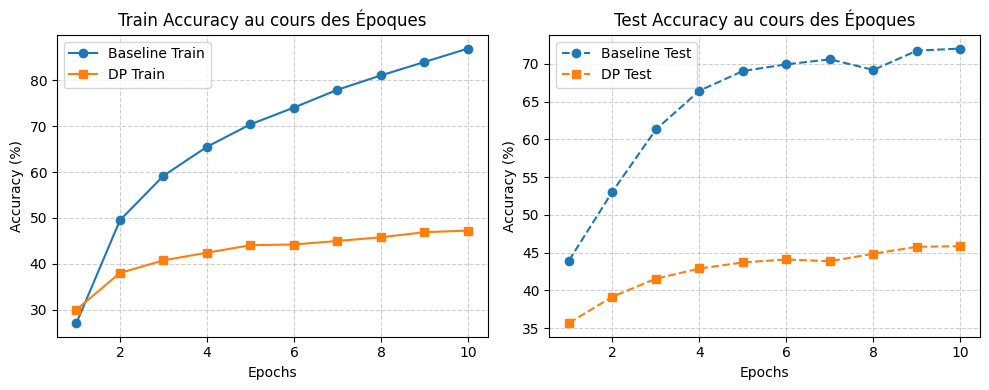

In [15]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 4))

# Graphe des Entraînements (Train)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, [x * 100 for x in baseline_ckpt_dict['train_acc_history']], label='Baseline Train', marker='o', color='tab:blue')
plt.plot(epochs_range, [x * 100 for x in dp_ckpt_dict['train_acc_history']], label='DP Train', marker='s', color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Train Accuracy au cours des Époques')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Graphe des Évaluations (Test)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, [x * 100 for x in baseline_ckpt_dict['test_acc_history']], label='Baseline Test', marker='o', linestyle='--', color='tab:blue')
plt.plot(epochs_range, [x * 100 for x in dp_ckpt_dict['test_acc_history']], label='DP Test', marker='s', linestyle='--', color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy au cours des Époques')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

## 3. Extract intermediate representations

We compare the activations of corresponding layers in the baseline and DP models.

We focus on the four main residual stages of ResNet18:
- `layer1`
- `layer2`
- `layer3`
- `layer4`

For each layer, we register a forward hook and collect the output activation tensor.

In [16]:
layers = [
    "layer1",
    "layer2",
    "layer3",
    "layer4",
    # "avgpool"
]

### Hooks

PyTorch forward hooks are used to intercept and duplicate intermediate activation tensors on the fly during the inference forward pass.

In [17]:
def get_activations(model, layer_names):
    activations = {}
    hooks = []

    def make_hook(name):
        def hook(module, inputs, output):
            activations[name] = output.detach()
        return hook

    for name, module in model.named_modules():
        if name in layer_names:
            hooks.append(module.register_forward_hook(make_hook(name)))

    return activations, hooks

## 4. Formulas for CKA

We use **linear CKA** (Centered Kernel Alignment) to compare activations between the baseline and DP models.

For each selected layer:
1. we extract activations from both models on several test batches,
2. we compute the CKA score batch by batch,
3. we average the scores across batches.

This is more stable than computing CKA on a single batch.

In [23]:
def gram_linear(x):
    return x @ x.T

def gram_rbf(x, sigma=None):
    # Calcul de la matrice des distances euclidiennes au carré
    dists = torch.cdist(x, x, p=2) ** 2
    if sigma is None:
        # Heuristique de la médiane pour déterminer sigma
        median_dist = torch.median(dists[dists > 0])
        sigma = torch.sqrt(median_dist)
    return torch.exp(-dists / (2 * (sigma ** 2)))

def center_gram(K):
    n = K.shape[0]
    H = torch.eye(n, device=K.device) - torch.ones(n, n, device=K.device) / n
    return H @ K @ H

def hsic(K, L):
    return torch.sum(K * L)

def compute_cka(X, Y, kernel_type="linear"):
    # Flatten des dimensions spatiales (N, C, H, W) -> (N, C*H*W)
    X = X.flatten(1)
    Y = Y.flatten(1)

    if kernel_type == "linear":
        K = center_gram(gram_linear(X))
        L = center_gram(gram_linear(Y))
    elif kernel_type == "gaussian":
        K = center_gram(gram_rbf(X))
        L = center_gram(gram_rbf(Y))
    else:
        raise ValueError("kernel_type doit être 'linear' ou 'gaussian'")

    hsic_xy = hsic(K, L)
    hsic_xx = hsic(K, K)
    hsic_yy = hsic(L, L)

    denom = torch.sqrt(hsic_xx * hsic_yy + 1e-12)
    return (hsic_xy / denom).item()

In [25]:
# Generic multi-batch CKA matrix extraction function to prevent code redundancy
def compute_cka_matrix(model_A, model_B, layers, loader, num_batches=30, kernel_type="linear"):
    model_A.eval()
    model_B.eval()
    
    # Dictionary to accumulate scores for each layer pair (i, j)
    cross_cka_accum = {(i, j): [] for i in range(len(layers)) for j in range(len(layers))}
    
    for batch_idx, (images, _) in enumerate(tqdm(loader, desc=f"Computing CKA ({kernel_type})", leave=False)):
        if batch_idx >= num_batches:
            break

        images = images.to(device, non_blocking=True)
        acts_A, hooks_A = get_activations(model_A, layers)
        acts_B, hooks_B = get_activations(model_B, layers)

        with torch.no_grad():
            model_A(images)
            model_B(images)

        for h in hooks_A: h.remove()
        for h in hooks_B: h.remove()

        for i, layer_A in enumerate(layers):
            for j, layer_B in enumerate(layers):
                score = compute_cka(acts_A[layer_A], acts_B[layer_B], kernel_type=kernel_type)
                cross_cka_accum[(i, j)].append(score)

        del images, acts_A, acts_B
        
    return cross_cka_accum

# Plotting function for CKA evaluations
import scipy.stats as stats

def plot_cka_results(cross_cka_accum, layers, title_suffix=""):
    num_layers = len(layers)
    matrix_means = np.zeros((num_layers, num_layers))
    diag_means = []
    diag_cis = []

    for i in range(num_layers):
        for j in range(num_layers):
            scores = cross_cka_accum[(i, j)]
            matrix_means[i, j] = np.mean(scores)
            if i == j:
                diag_means.append(matrix_means[i, j])
                std_err = stats.sem(scores)
                # 95% Confidence Interval calculation using Student-t distribution
                ci_range = std_err * stats.t.ppf((1 + 0.95) / 2., len(scores) - 1) if len(scores) > 1 else 0
                diag_cis.append(ci_range)

    # 1. Diagonal Plot (Identical layers) with 95% Confidence Intervals
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.bar(layers, diag_means, yerr=diag_cis, capsize=5, color='skyblue', edgecolor='black')
    plt.ylabel("CKA Score (with 95% CI)")
    plt.title(f"Diagonal CKA Similarity\n{title_suffix}")
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 2. Inter-layer Cross Matrix Plot
    plt.subplot(1, 2, 2)
    cax = plt.imshow(matrix_means, cmap='viridis', vmin=0, vmax=1, origin='lower')
    plt.colorbar(cax, label='CKA Similarity')
    plt.xticks(range(num_layers), layers)
    plt.yticks(range(num_layers), layers)
    plt.xlabel("Model B")
    plt.ylabel("Model A")
    plt.title(f"Inter-layer CKA Matrix\n{title_suffix}")

    for i in range(num_layers):
        for j in range(num_layers):
            val = matrix_means[i, j]
            plt.text(j, i, f"{val:.2f}", 
                     ha="center", va="center", 
                     color="white" if val < 0.6 else "black")

    plt.tight_layout()
    plt.show()
    
    # Text output for the diagonal confidence intervals
    print("--- Diagonal Scores (± 95% CI) ---")
    for idx, layer in enumerate(layers):
        print(f"{layer} : {diag_means[idx]:.4f} (± {diag_cis[idx]:.4f})")

## 5. Analysis: DP Model vs Baseline Model

Computing CKA between Baseline (Seed 42) and DP (Seed 42) using linear kernel...


Computing CKA (linear):   0%|          | 0/40 [00:00<?, ?it/s]

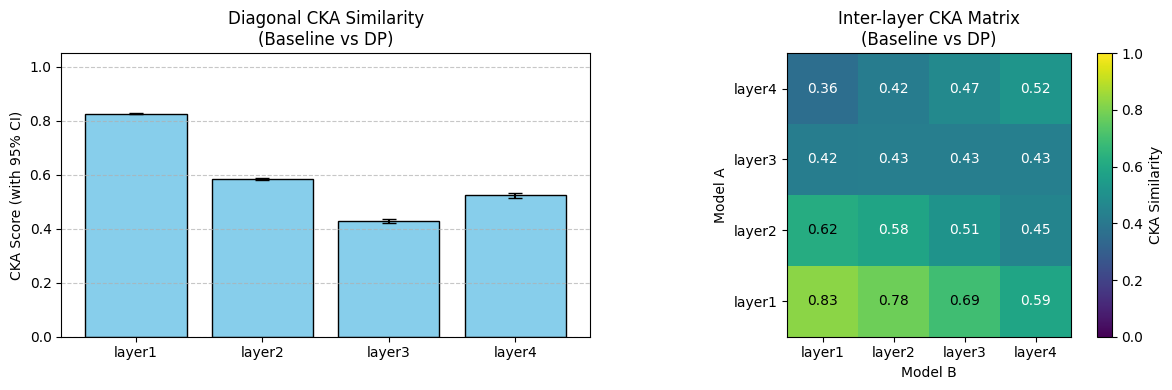

--- Diagonal Scores (± 95% CI) ---
layer1 : 0.8264 (± 0.0019)
layer2 : 0.5833 (± 0.0043)
layer3 : 0.4288 (± 0.0069)
layer4 : 0.5231 (± 0.0103)


In [26]:
KERNEL_CHOICE = "linear"  # @param ["linear", "gaussian"]

print(f"Computing CKA between Baseline (Seed 42) and DP (Seed 42) using {KERNEL_CHOICE} kernel...")
accum_dp_vs_base = compute_cka_matrix(baseline, dp_model, layers, test_loader, num_batches=NUM_CKA_BATCHES, kernel_type=KERNEL_CHOICE)
plot_cka_results(accum_dp_vs_base, layers, title_suffix="(Baseline vs DP)")

## 6. Baseline vs Baseline (Robustness to Random Seeds)
To effectively measure the impact of Differential Privacy, we establish a reference baseline by calculating the natural variance between two standard networks trained with different random seeds.
**Manually change the checkpoint paths below to select your baseline networks.**

/tmp/ipykernel_1713472/3975070838.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_base_A.load_state_dict(torch.load(CKPT_BASE_A, map_location=device)['model_state_

Computing CKA between two Baseline models (Seed 42 vs Seed 43)...


Computing CKA (linear):   0%|          | 0/40 [00:00<?, ?it/s]

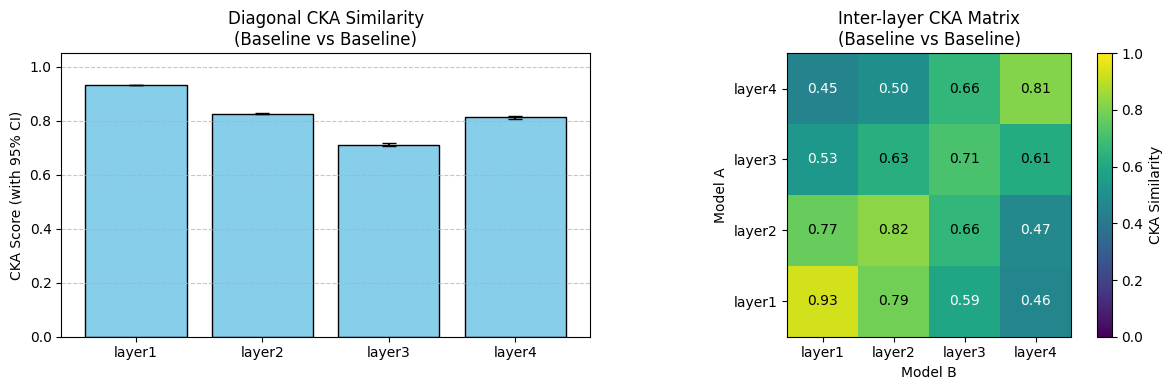

--- Diagonal Scores (± 95% CI) ---
layer1 : 0.9311 (± 0.0008)
layer2 : 0.8248 (± 0.0019)
layer3 : 0.7113 (± 0.0051)
layer4 : 0.8131 (± 0.0056)


In [27]:
# MANUAL CHECKPOINT SELECTION FOR BASELINE MODELS
CKPT_BASE_A = NETWORKS_DIR / "baseline_resnet18_eps10_delta1e08_epoch10_C1.2_seed42_i0.pth"
CKPT_BASE_B = NETWORKS_DIR / "baseline_resnet18_eps10_delta1e08_epoch10_C1.2_seed43_i0.pth"

# Model instantiation
model_base_A = build_baseline_model().to(device)
model_base_B = build_baseline_model().to(device)

model_base_A.load_state_dict(torch.load(CKPT_BASE_A, map_location=device)['model_state_dict'])
model_base_B.load_state_dict(torch.load(CKPT_BASE_B, map_location=device)['model_state_dict'])

print("Computing CKA between two Baseline models (Seed 42 vs Seed 43)...")
accum_base_vs_base = compute_cka_matrix(model_base_A, model_base_B, layers, test_loader, num_batches=NUM_CKA_BATCHES, kernel_type=KERNEL_CHOICE)
plot_cka_results(accum_base_vs_base, layers, title_suffix="(Baseline vs Baseline)")

## 7. DP vs DP (Representation Stability under Privacy Constraints)

Similarly, we analyze if two DP-SGD runs using identical privacy hyperparameters but different random seeds converge toward similar internal representations.

/tmp/ipykernel_1713472/351796864.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dp_A.load_state_dict(torch.load(CKPT_DP_A, map_location=device)['model_state_dict'

Computing CKA between two DP models (Seed 42 vs Seed 43)...


Computing CKA (linear):   0%|          | 0/40 [00:00<?, ?it/s]

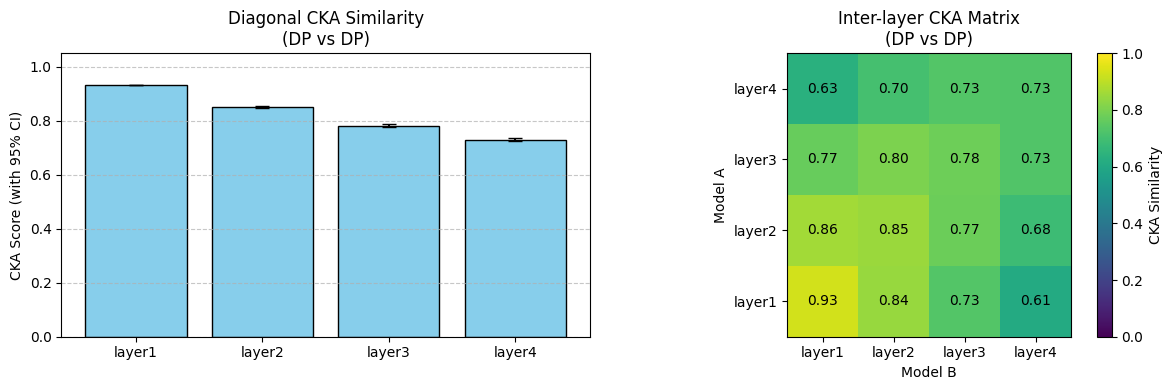

--- Diagonal Scores (± 95% CI) ---
layer1 : 0.9319 (± 0.0011)
layer2 : 0.8512 (± 0.0032)
layer3 : 0.7811 (± 0.0051)
layer4 : 0.7298 (± 0.0064)


In [29]:
# MANUAL CHECKPOINT SELECTION FOR DP MODELS
CKPT_DP_A = NETWORKS_DIR / "dp_resnet18_eps10_delta1e08_epoch10_C1.2_seed42_i0.pth"
CKPT_DP_B = NETWORKS_DIR / "dp_resnet18_eps10_delta1e08_epoch10_C1.2_seed43_i0.pth"

# Model instantiation
model_dp_A = build_dp_model().to(device)
model_dp_B = build_dp_model().to(device)

model_dp_A.load_state_dict(torch.load(CKPT_DP_A, map_location=device)['model_state_dict'])
model_dp_B.load_state_dict(torch.load(CKPT_DP_B, map_location=device)['model_state_dict'])

print("Computing CKA between two DP models (Seed 42 vs Seed 43)...")
accum_dp_vs_dp = compute_cka_matrix(model_dp_A, model_dp_B, layers, test_loader, num_batches=NUM_CKA_BATCHES, kernel_type=KERNEL_CHOICE)
plot_cka_results(accum_dp_vs_dp, layers, title_suffix="(DP vs DP)")

## 8. Comparing privacy budget $\epsilon$

### How to compare different Epsilon levels?
To track representation drifts across a spectrum of epsilon values (e.g., $\epsilon \in \{2, 8, 10\}$), each DP model is evaluated directly **against the non-private reference Baseline model**. 

Stronger privacy requirements (lower $\epsilon$) inject more noise during training, which typically forces internal features to deviate from the baseline behavior (yielding lower CKA values). As $\epsilon$ grows, representations should gradually align with the standard baseline.

We construct a summary matrix of Epsilon vs Layers using the mean diagonal CKA values.

In [ ]:
# 1. Define available epsilons and their corresponding checkpoint files
epsilon_list = [2, 8, 10]  # Adjust based on your available files
epsilon_ckpts = {
    2:  NETWORKS_DIR / "dp_resnet18_eps2_delta1e08_epoch10_C1.2_seed42_i0.pth",
    8:  NETWORKS_DIR / "dp_resnet18_eps8_delta1e08_epoch10_C1.2_seed42_i0.pth",
    10: NETWORKS_DIR / "dp_resnet18_eps10_delta1e08_epoch10_C1.2_seed42_i0.pth",
}

# The baseline model (seed 42) serves as our absolute target reference
baseline_ref = baseline 

# Matrix array to hold mean diagonal CKA scores for each epsilon level
epsilon_layer_matrix = np.zeros((len(epsilon_list), len(layers)))

for eps_idx, eps in enumerate(epsilon_list):
    ckpt_path = epsilon_ckpts[eps]
    if not ckpt_path.exists():
        print(f"Warning: Checkpoint for epsilon={eps} not found at: {ckpt_path}. Filled with zeros.")
        continue
        
    print(f"Analyzing privacy budget: epsilon = {eps}...")
    # Load temporary DP model instance for the current epsilon
    tmp_dp_model = build_dp_model().to(device)
    tmp_dp_model.load_state_dict(torch.load(ckpt_path, map_location=device)['model_state_dict'])
    
    # Run alignment tracking against the baseline model
    accum_eps = compute_cka_matrix(baseline_ref, tmp_dp_model, layers, test_loader, num_batches=NUM_CKA_BATCHES, kernel_type=KERNEL_CHOICE)
    
    # Store diagonal outputs (layer i vs layer i)
    for l_idx in range(len(layers)):
        epsilon_layer_matrix[eps_idx, l_idx] = np.mean(accum_eps[(l_idx, l_idx)])
        
    del tmp_dp_model

# --- Generate Multi-Epsilon Heatmap Summary ---
plt.figure(figsize=(8, 5))
cax = plt.imshow(epsilon_layer_matrix, cmap='plasma', vmin=0, vmax=1, origin='lower')
plt.colorbar(cax, label='CKA Similarity with Baseline')

plt.xticks(range(len(layers)), layers)
plt.yticks(range(len(epsilon_list)), [f"$\epsilon$ = {e}" for e in epsilon_list])
plt.xlabel("Network Layers")
plt.ylabel("Privacy Constraint Level (DP)")
plt.title("Evolution of Representation Similarity to Baseline across $\epsilon$")

# Numeric annotations setup
for i in range(len(epsilon_list)):
    for j in range(len(layers)):
        val = epsilon_layer_matrix[i, j]
        plt.text(j, i, f"{val:.2f}", 
                 ha="center", va="center", 
                 color="white" if val < 0.5 else "black")

plt.tight_layout()
plt.show()

------------------------ old

------------------------ 

### 4.2 Run on several batches

In [19]:
NUM_CKA_BATCHES = 30  # use the first 10 test batches for a more stable estimate

cka_scores_per_layer = {layer: [] for layer in layers}

for batch_idx, (images, labels) in enumerate(tqdm(test_loader, desc="CKA batches")):
    if batch_idx >= NUM_CKA_BATCHES:
        break

    images = images.to(device, non_blocking=True)

    acts_base, hooks_base = get_activations(baseline, layers)
    acts_dp, hooks_dp = get_activations(dp_model, layers)

    with torch.no_grad():
        baseline(images)
        dp_model(images)

    for h in hooks_base:
        h.remove()
    for h in hooks_dp:
        h.remove()

    for layer in layers:
        score = linear_cka(acts_base[layer], acts_dp[layer])
        cka_scores_per_layer[layer].append(score)

    del images, acts_base, acts_dp

CKA batches:   0%|          | 0/40 [00:00<?, ?it/s]

## 5. Compute CKA

Similarity by layer.

In [20]:
# # MODIFICATION ICI : Faire la moyenne des scores accumulés par lot
# cka_scores = {}

# for layer in layers:
#     # On fait la moyenne des scores obtenus sur les NUM_CKA_BATCHES
#     mean_score = np.mean(cka_scores_per_layer[layer])
#     cka_scores[layer] = mean_score
#     print(f"{layer} : {mean_score:.4f}")

import scipy.stats as stats

cka_means = []
cka_cis = []
layer_labels = list(cka_scores_per_layer.keys())

for layer in layer_labels:
    scores = cka_scores_per_layer[layer]
    mean_score = np.mean(scores)
    cka_means.append(mean_score)
    
    # Calcul de l'intervalle de confiance à 95%
    std_err = stats.sem(scores)  # Erreur type de la moyenne
    # Multiplicateur pour 95% de confiance (approx. 1.96)
    ci_range = std_err * stats.t.ppf((1 + 0.95) / 2., len(scores) - 1) if len(scores) > 1 else 0
    cka_cis.append(ci_range)
    
    print(f"{layer} : {mean_score:.4f} (± {ci_range:.4f})")


layer1 : 0.8254 (± 0.0016)
layer2 : 0.5834 (± 0.0041)
layer3 : 0.4282 (± 0.0066)
layer4 : 0.5249 (± 0.0094)


## 6. Plot

Similarity across layers.

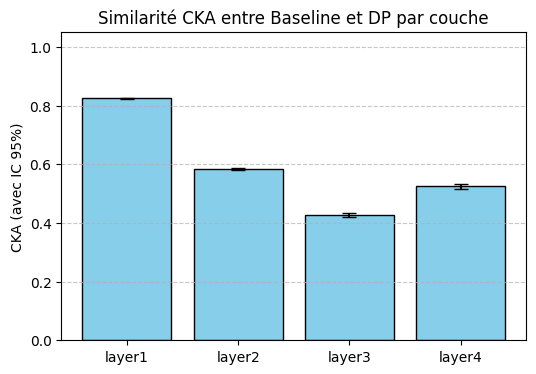

In [21]:
# --- Génération du Graphique avec Barres d'Erreur ---
plt.figure(figsize=(6, 4))
plt.bar(
    layer_labels,
    cka_means,
    yerr=cka_cis,          # Ajoute la barre d'erreur (Intervalle de confiance)
    capsize=5,             # Petites barres horizontales aux extrémités
    color='skyblue',
    edgecolor='black'
)
plt.ylabel("CKA (avec IC 95%)")
plt.title("Similarité CKA entre Baseline et DP par couche")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Matrice CKA:   0%|          | 0/40 [00:00<?, ?it/s]

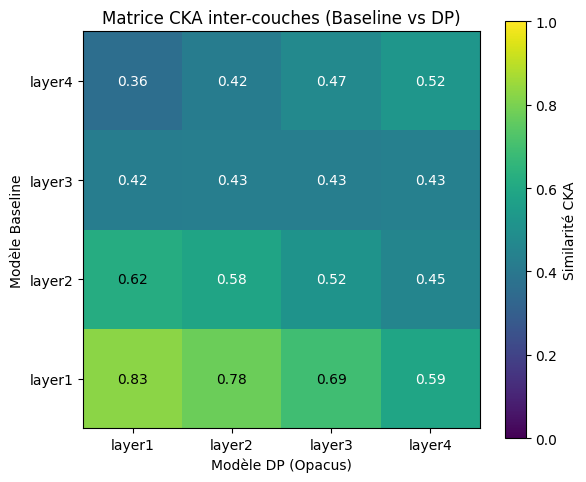

In [22]:
# 1. Initialisation d'une matrice 4x4 vide
matrix_scores = np.zeros((len(layers), len(layers)))

# 2. Calcul du CKA croisé sur les batches
# On ré-utilise une structure similaire pour accumuler les scores de chaque paire (i, j)
cross_cka_accum = {(i, j): [] for i in range(len(layers)) for j in range(len(layers))}

for batch_idx, (images, labels) in enumerate(tqdm(test_loader, desc="Matrice CKA")):
    if batch_idx >= NUM_CKA_BATCHES:
        break

    images = images.to(device, non_blocking=True)
    acts_base, hooks_base = get_activations(baseline, layers)
    acts_dp, hooks_dp = get_activations(dp_model, layers)

    with torch.no_grad():
        baseline(images)
        dp_model(images)

    for h in hooks_base: h.remove()
    for h in hooks_dp: h.remove()

    # Remplissage des scores croisés pour ce batch
    for i, layer_base in enumerate(layers):
        for j, layer_dp in enumerate(layers):
            score = linear_cka(acts_base[layer_base], acts_dp[layer_dp])
            cross_cka_accum[(i, j)].append(score)

# 3. Moyenne des scores pour remplir la matrice finale
for i in range(len(layers)):
    for j in range(len(layers)):
        matrix_scores[i, j] = np.mean(cross_cka_accum[(i, j)])

# 4. Affichage de la Heatmap 4x4
plt.figure(figsize=(6, 5))
cax = plt.imshow(matrix_scores, cmap='viridis', vmin=0, vmax=1, origin='lower')
plt.colorbar(cax, label='Similarité CKA')

# Configuration des axes
plt.xticks(range(len(layers)), layers)
plt.yticks(range(len(layers)), layers)
plt.xlabel("Modèle DP (Opacus)")
plt.ylabel("Modèle Baseline")
plt.title("Matrice CKA inter-couches (Baseline vs DP)")

# Ajout des valeurs numériques dans les cases pour faciliter la lecture à l'oral
for i in range(len(layers)):
    for j in range(len(layers)):
        plt.text(j, i, f"{matrix_scores[i, j]:.2f}", 
                 ha="center", va="center", 
                 color="white" if matrix_scores[i, j] < 0.6 else "black")

plt.tight_layout()
plt.show()